# 🏆 2026 FIFA World Cup — Live Predictor & Full-Tournament Simulator

A **self-contained, updateable** forecasting notebook. Run it top-to-bottom and it predicts a score for **every
match** of the tournament — all 72 group games and the entire knockout bracket through the final.

### 🔴 What makes this *live*
As real matches are played, type their results into **one cell (§4)** and re-run. Each result does two things:
1. **Re-trains team strength** — the actual score is added to the data, so Elo and the goals model update (a team
   that wins big in the group stage gets stronger predictions in the knockouts).
2. **Fixes the bracket** — the real winner advances, so every downstream prediction is conditioned on what actually
   happened.

You enter **just the score** for group games. For **knockout** games you also flag a **penalty-shootout winner** when
the score is level. Re-running produces fresh predictions for every match still to come.

---
**Pipeline:** download free data → clean → in-house Elo → time-weighted Poisson goals model (+Elo feature) →
out-of-sample validation → encode the real 2026 format (groups, FIFA's 495-row third-place table, exact bracket) →
condition on your entered results → Monte Carlo → **predicted scoreline for every match** + champion probabilities.

> ⚠️ Probabilistic forecasts, not certainties. Cited bookmaker/academic numbers are pre-tournament benchmarks.

## 0 · Setup

In [1]:
import importlib, subprocess, sys
for pkg in ["pandas", "numpy", "scipy", "scikit-learn", "matplotlib"]:
    name = "sklearn" if pkg == "scikit-learn" else pkg
    try: importlib.import_module(name)
    except ImportError: subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

import numpy as np, pandas as pd, os, time, warnings
from scipy.stats import poisson
from scipy import sparse
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import PoissonRegressor
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
RNG_SEED = 42
pd.set_option("display.width", 140); pd.set_option("display.max_rows", 120)
print("ready")

ready


c:\Users\User\Documents\WorldCup2026Predictor\.venv\lib\site-packages\matplotlib\projections\__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1 · Data acquisition
Free, public-domain dataset [`martj42/international_results`](https://github.com/martj42/international_results)
(~49k men's internationals since 1872). Cached locally on first run so later runs work offline.

In [2]:
DATA_DIR = "wc2026_data"; os.makedirs(DATA_DIR, exist_ok=True)
BASE = "https://raw.githubusercontent.com/martj42/international_results/master"
def get(fname):
    path = os.path.join(DATA_DIR, fname)
    if os.path.exists(path): return pd.read_csv(path)
    print("downloading", fname, "…"); df = pd.read_csv(f"{BASE}/{fname}"); df.to_csv(path, index=False); return df
results_raw = get("results.csv"); shootouts = get("shootouts.csv"); former_names = get("former_names.csv")
print(f"results: {len(results_raw):,} rows | {results_raw.date.min()} → {results_raw.date.max()}")

results: 49,437 rows | 1872-11-30 → 2026-06-27


## 2 · Cleaning
Parse dates, drop unplayed fixtures (the data already lists 2026 games with blank scores — they must not train the
model), cast scores, normalise the neutral flag. Produces `matches_hist`, the historical training base.

In [3]:
matches_hist = results_raw.copy()
matches_hist["date"] = pd.to_datetime(matches_hist["date"])
matches_hist = matches_hist.dropna(subset=["home_score", "away_score"]).copy()
matches_hist["home_score"] = matches_hist["home_score"].astype(int)
matches_hist["away_score"] = matches_hist["away_score"].astype(int)
matches_hist["neutral_b"]  = matches_hist["neutral"].astype(str).str.upper().eq("TRUE")
matches_hist = matches_hist.sort_values("date").reset_index(drop=True)
print(f"historical matches: {len(matches_hist):,} | {matches_hist.date.min().date()} → {matches_hist.date.max().date()}")

historical matches: 49,365 | 1872-11-30 → 2026-06-06


## 3 · The 2026 tournament structure
First **48-team** World Cup: **12 groups of four** (A–L), hosts **USA / Canada / Mexico**. Top two of each group plus
the **eight best third-placed teams** reach the **Round of 32**, then R16 → QF → SF → **final, 19 July 2026**.
Names are pre-matched to the dataset's spelling.

In [4]:
GROUPS = {
    "A": ["Mexico", "South Africa", "South Korea", "Czech Republic"],
    "B": ["Canada", "Bosnia and Herzegovina", "Qatar", "Switzerland"],
    "C": ["Brazil", "Morocco", "Haiti", "Scotland"],
    "D": ["United States", "Paraguay", "Australia", "Turkey"],
    "E": ["Germany", "Curaçao", "Ivory Coast", "Ecuador"],
    "F": ["Netherlands", "Japan", "Sweden", "Tunisia"],
    "G": ["Belgium", "Egypt", "Iran", "New Zealand"],
    "H": ["Spain", "Cape Verde", "Saudi Arabia", "Uruguay"],
    "I": ["France", "Senegal", "Iraq", "Norway"],
    "J": ["Argentina", "Algeria", "Austria", "Jordan"],
    "K": ["Portugal", "DR Congo", "Uzbekistan", "Colombia"],
    "L": ["England", "Croatia", "Ghana", "Panama"],
}
HOSTS = {"United States", "Canada", "Mexico"}
all_teams = [t for g in GROUPS.values() for t in g]
assert len(all_teams) == len(set(all_teams)) == 48
known = set(matches_hist.home_team) | set(matches_hist.away_team)
print("48 teams, all found in dataset:", all(t in known for t in all_teams))

48 teams, all found in dataset: True


### 3a · FIFA's official best-third-placed allocation table
Which R32 slot each qualifying third-placed team takes depends on *which* eight groups they come from — FIFA
publishes a row for every one of the $\binom{12}{8}=495$ combinations. Embedded verbatim and validated below.

In [5]:
THIRD_PLACE_TABLE_RAW = """
EFGHIJKL EJIFHGLK
DFGHIJKL HGIDJFLK
DEGHIJKL EJIDHGLK
DEFHIJKL EJIDHFLK
DEFGIJKL EGIDJFLK
DEFGHJKL EGJDHFLK
DEFGHIKL EGIDHFLK
DEFGHIJL EGJDHFLI
DEFGHIJK EGJDHFIK
CFGHIJKL HGICJFLK
CEGHIJKL EJICHGLK
CEFHIJKL EJICHFLK
CEFGIJKL EGICJFLK
CEFGHJKL EGJCHFLK
CEFGHIKL EGICHFLK
CEFGHIJL EGJCHFLI
CEFGHIJK EGJCHFIK
CDGHIJKL HGICJDLK
CDFHIJKL CJIDHFLK
CDFGIJKL CGIDJFLK
CDFGHJKL CGJDHFLK
CDFGHIKL CGIDHFLK
CDFGHIJL CGJDHFLI
CDFGHIJK CGJDHFIK
CDEHIJKL EJICHDLK
CDEGIJKL EGICJDLK
CDEGHJKL EGJCHDLK
CDEGHIKL EGICHDLK
CDEGHIJL EGJCHDLI
CDEGHIJK EGJCHDIK
CDEFIJKL CJEDIFLK
CDEFHJKL CJEDHFLK
CDEFHIKL CEIDHFLK
CDEFHIJL CJEDHFLI
CDEFHIJK CJEDHFIK
CDEFGJKL CGEDJFLK
CDEFGIKL CGEDIFLK
CDEFGIJL CGEDJFLI
CDEFGIJK CGEDJFIK
CDEFGHKL CGEDHFLK
CDEFGHJL CGJDHFLE
CDEFGHJK CGJDHFEK
CDEFGHIL CGEDHFLI
CDEFGHIK CGEDHFIK
CDEFGHIJ CGJDHFEI
BFGHIJKL HJBFIGLK
BEGHIJKL EJIBHGLK
BEFHIJKL EJBFIHLK
BEFGIJKL EJBFIGLK
BEFGHJKL EJBFHGLK
BEFGHIKL EGBFIHLK
BEFGHIJL EJBFHGLI
BEFGHIJK EJBFHGIK
BDGHIJKL HJBDIGLK
BDFHIJKL HJBDIFLK
BDFGIJKL IGBDJFLK
BDFGHJKL HGBDJFLK
BDFGHIKL HGBDIFLK
BDFGHIJL HGBDJFLI
BDFGHIJK HGBDJFIK
BDEHIJKL EJBDIHLK
BDEGIJKL EJBDIGLK
BDEGHJKL EJBDHGLK
BDEGHIKL EGBDIHLK
BDEGHIJL EJBDHGLI
BDEGHIJK EJBDHGIK
BDEFIJKL EJBDIFLK
BDEFHJKL EJBDHFLK
BDEFHIKL EIBDHFLK
BDEFHIJL EJBDHFLI
BDEFHIJK EJBDHFIK
BDEFGJKL EGBDJFLK
BDEFGIKL EGBDIFLK
BDEFGIJL EGBDJFLI
BDEFGIJK EGBDJFIK
BDEFGHKL EGBDHFLK
BDEFGHJL HGBDJFLE
BDEFGHJK HGBDJFEK
BDEFGHIL EGBDHFLI
BDEFGHIK EGBDHFIK
BDEFGHIJ HGBDJFEI
BCGHIJKL HJBCIGLK
BCFHIJKL HJBCIFLK
BCFGIJKL IGBCJFLK
BCFGHJKL HGBCJFLK
BCFGHIKL HGBCIFLK
BCFGHIJL HGBCJFLI
BCFGHIJK HGBCJFIK
BCEHIJKL EJBCIHLK
BCEGIJKL EJBCIGLK
BCEGHJKL EJBCHGLK
BCEGHIKL EGBCIHLK
BCEGHIJL EJBCHGLI
BCEGHIJK EJBCHGIK
BCEFIJKL EJBCIFLK
BCEFHJKL EJBCHFLK
BCEFHIKL EIBCHFLK
BCEFHIJL EJBCHFLI
BCEFHIJK EJBCHFIK
BCEFGJKL EGBCJFLK
BCEFGIKL EGBCIFLK
BCEFGIJL EGBCJFLI
BCEFGIJK EGBCJFIK
BCEFGHKL EGBCHFLK
BCEFGHJL HGBCJFLE
BCEFGHJK HGBCJFEK
BCEFGHIL EGBCHFLI
BCEFGHIK EGBCHFIK
BCEFGHIJ HGBCJFEI
BCDHIJKL HJBCIDLK
BCDGIJKL IGBCJDLK
BCDGHJKL HGBCJDLK
BCDGHIKL HGBCIDLK
BCDGHIJL HGBCJDLI
BCDGHIJK HGBCJDIK
BCDFIJKL CJBDIFLK
BCDFHJKL CJBDHFLK
BCDFHIKL CIBDHFLK
BCDFHIJL CJBDHFLI
BCDFHIJK CJBDHFIK
BCDFGJKL CGBDJFLK
BCDFGIKL CGBDIFLK
BCDFGIJL CGBDJFLI
BCDFGIJK CGBDJFIK
BCDFGHKL CGBDHFLK
BCDFGHJL CGBDHFLJ
BCDFGHJK HGBCJFDK
BCDFGHIL CGBDHFLI
BCDFGHIK CGBDHFIK
BCDFGHIJ HGBCJFDI
BCDEIJKL EJBCIDLK
BCDEHJKL EJBCHDLK
BCDEHIKL EIBCHDLK
BCDEHIJL EJBCHDLI
BCDEHIJK EJBCHDIK
BCDEGJKL EGBCJDLK
BCDEGIKL EGBCIDLK
BCDEGIJL EGBCJDLI
BCDEGIJK EGBCJDIK
BCDEGHKL EGBCHDLK
BCDEGHJL HGBCJDLE
BCDEGHJK HGBCJDEK
BCDEGHIL EGBCHDLI
BCDEGHIK EGBCHDIK
BCDEGHIJ HGBCJDEI
BCDEFJKL CJBDEFLK
BCDEFIKL CEBDIFLK
BCDEFIJL CJBDEFLI
BCDEFIJK CJBDEFIK
BCDEFHKL CEBDHFLK
BCDEFHJL CJBDHFLE
BCDEFHJK CJBDHFEK
BCDEFHIL CEBDHFLI
BCDEFHIK CEBDHFIK
BCDEFHIJ CJBDHFEI
BCDEFGKL CGBDEFLK
BCDEFGJL CGBDJFLE
BCDEFGJK CGBDJFEK
BCDEFGIL CGBDEFLI
BCDEFGIK CGBDEFIK
BCDEFGIJ CGBDJFEI
BCDEFGHL CGBDHFLE
BCDEFGHK CGBDHFEK
BCDEFGHJ HGBCJFDE
BCDEFGHI CGBDHFEI
AFGHIJKL HJIFAGLK
AEGHIJKL EJIAHGLK
AEFHIJKL EJIFAHLK
AEFGIJKL EJIFAGLK
AEFGHJKL EGJFAHLK
AEFGHIKL EGIFAHLK
AEFGHIJL EGJFAHLI
AEFGHIJK EGJFAHIK
ADGHIJKL HJIDAGLK
ADFHIJKL HJIDAFLK
ADFGIJKL IGJDAFLK
ADFGHJKL HGJDAFLK
ADFGHIKL HGIDAFLK
ADFGHIJL HGJDAFLI
ADFGHIJK HGJDAFIK
ADEHIJKL EJIDAHLK
ADEGIJKL EJIDAGLK
ADEGHJKL EGJDAHLK
ADEGHIKL EGIDAHLK
ADEGHIJL EGJDAHLI
ADEGHIJK EGJDAHIK
ADEFIJKL EJIDAFLK
ADEFHJKL HJEDAFLK
ADEFHIKL HEIDAFLK
ADEFHIJL HJEDAFLI
ADEFHIJK HJEDAFIK
ADEFGJKL EGJDAFLK
ADEFGIKL EGIDAFLK
ADEFGIJL EGJDAFLI
ADEFGIJK EGJDAFIK
ADEFGHKL HGEDAFLK
ADEFGHJL HGJDAFLE
ADEFGHJK HGJDAFEK
ADEFGHIL HGEDAFLI
ADEFGHIK HGEDAFIK
ADEFGHIJ HGJDAFEI
ACGHIJKL HJICAGLK
ACFHIJKL HJICAFLK
ACFGIJKL IGJCAFLK
ACFGHJKL HGJCAFLK
ACFGHIKL HGICAFLK
ACFGHIJL HGJCAFLI
ACFGHIJK HGJCAFIK
ACEHIJKL EJICAHLK
ACEGIJKL EJICAGLK
ACEGHJKL EGJCAHLK
ACEGHIKL EGICAHLK
ACEGHIJL EGJCAHLI
ACEGHIJK EGJCAHIK
ACEFIJKL EJICAFLK
ACEFHJKL HJECAFLK
ACEFHIKL HEICAFLK
ACEFHIJL HJECAFLI
ACEFHIJK HJECAFIK
ACEFGJKL EGJCAFLK
ACEFGIKL EGICAFLK
ACEFGIJL EGJCAFLI
ACEFGIJK EGJCAFIK
ACEFGHKL HGECAFLK
ACEFGHJL HGJCAFLE
ACEFGHJK HGJCAFEK
ACEFGHIL HGECAFLI
ACEFGHIK HGECAFIK
ACEFGHIJ HGJCAFEI
ACDHIJKL HJICADLK
ACDGIJKL IGJCADLK
ACDGHJKL HGJCADLK
ACDGHIKL HGICADLK
ACDGHIJL HGJCADLI
ACDGHIJK HGJCADIK
ACDFIJKL CJIDAFLK
ACDFHJKL HJFCADLK
ACDFHIKL HFICADLK
ACDFHIJL HJFCADLI
ACDFHIJK HJFCADIK
ACDFGJKL CGJDAFLK
ACDFGIKL CGIDAFLK
ACDFGIJL CGJDAFLI
ACDFGIJK CGJDAFIK
ACDFGHKL HGFCADLK
ACDFGHJL CGJDAFLH
ACDFGHJK HGJCAFDK
ACDFGHIL HGFCADLI
ACDFGHIK HGFCADIK
ACDFGHIJ HGJCAFDI
ACDEIJKL EJICADLK
ACDEHJKL HJECADLK
ACDEHIKL HEICADLK
ACDEHIJL HJECADLI
ACDEHIJK HJECADIK
ACDEGJKL EGJCADLK
ACDEGIKL EGICADLK
ACDEGIJL EGJCADLI
ACDEGIJK EGJCADIK
ACDEGHKL HGECADLK
ACDEGHJL HGJCADLE
ACDEGHJK HGJCADEK
ACDEGHIL HGECADLI
ACDEGHIK HGECADIK
ACDEGHIJ HGJCADEI
ACDEFJKL CJEDAFLK
ACDEFIKL CEIDAFLK
ACDEFIJL CJEDAFLI
ACDEFIJK CJEDAFIK
ACDEFHKL HEFCADLK
ACDEFHJL HJFCADLE
ACDEFHJK HJECAFDK
ACDEFHIL HEFCADLI
ACDEFHIK HEFCADIK
ACDEFHIJ HJECAFDI
ACDEFGKL CGEDAFLK
ACDEFGJL CGJDAFLE
ACDEFGJK CGJDAFEK
ACDEFGIL CGEDAFLI
ACDEFGIK CGEDAFIK
ACDEFGIJ CGJDAFEI
ACDEFGHL HGFCADLE
ACDEFGHK HGECAFDK
ACDEFGHJ HGJCAFDE
ACDEFGHI HGECAFDI
ABGHIJKL HJBAIGLK
ABFHIJKL HJBAIFLK
ABFGIJKL IJBFAGLK
ABFGHJKL HJBFAGLK
ABFGHIKL HGBAIFLK
ABFGHIJL HJBFAGLI
ABFGHIJK HJBFAGIK
ABEHIJKL EJBAIHLK
ABEGIJKL EJBAIGLK
ABEGHJKL EJBAHGLK
ABEGHIKL EGBAIHLK
ABEGHIJL EJBAHGLI
ABEGHIJK EJBAHGIK
ABEFIJKL EJBAIFLK
ABEFHJKL EJBFAHLK
ABEFHIKL EIBFAHLK
ABEFHIJL EJBFAHLI
ABEFHIJK EJBFAHIK
ABEFGJKL EJBFAGLK
ABEFGIKL EGBAIFLK
ABEFGIJL EJBFAGLI
ABEFGIJK EJBFAGIK
ABEFGHKL EGBFAHLK
ABEFGHJL HJBFAGLE
ABEFGHJK HJBFAGEK
ABEFGHIL EGBFAHLI
ABEFGHIK EGBFAHIK
ABEFGHIJ HJBFAGEI
ABDHIJKL IJBDAHLK
ABDGIJKL IJBDAGLK
ABDGHJKL HJBDAGLK
ABDGHIKL IGBDAHLK
ABDGHIJL HJBDAGLI
ABDGHIJK HJBDAGIK
ABDFIJKL IJBDAFLK
ABDFHJKL HJBDAFLK
ABDFHIKL HIBDAFLK
ABDFHIJL HJBDAFLI
ABDFHIJK HJBDAFIK
ABDFGJKL FJBDAGLK
ABDFGIKL IGBDAFLK
ABDFGIJL FJBDAGLI
ABDFGIJK FJBDAGIK
ABDFGHKL HGBDAFLK
ABDFGHJL HGBDAFLJ
ABDFGHJK HGBDAFJK
ABDFGHIL HGBDAFLI
ABDFGHIK HGBDAFIK
ABDFGHIJ HGBDAFIJ
ABDEIJKL EJBAIDLK
ABDEHJKL EJBDAHLK
ABDEHIKL EIBDAHLK
ABDEHIJL EJBDAHLI
ABDEHIJK EJBDAHIK
ABDEGJKL EJBDAGLK
ABDEGIKL EGBAIDLK
ABDEGIJL EJBDAGLI
ABDEGIJK EJBDAGIK
ABDEGHKL EGBDAHLK
ABDEGHJL HJBDAGLE
ABDEGHJK HJBDAGEK
ABDEGHIL EGBDAHLI
ABDEGHIK EGBDAHIK
ABDEGHIJ HJBDAGEI
ABDEFJKL EJBDAFLK
ABDEFIKL EIBDAFLK
ABDEFIJL EJBDAFLI
ABDEFIJK EJBDAFIK
ABDEFHKL HEBDAFLK
ABDEFHJL HJBDAFLE
ABDEFHJK HJBDAFEK
ABDEFHIL HEBDAFLI
ABDEFHIK HEBDAFIK
ABDEFHIJ HJBDAFEI
ABDEFGKL EGBDAFLK
ABDEFGJL EGBDAFLJ
ABDEFGJK EGBDAFJK
ABDEFGIL EGBDAFLI
ABDEFGIK EGBDAFIK
ABDEFGIJ EGBDAFIJ
ABDEFGHL HGBDAFLE
ABDEFGHK HGBDAFEK
ABDEFGHJ HGBDAFEJ
ABDEFGHI HGBDAFEI
ABCHIJKL IJBCAHLK
ABCGIJKL IJBCAGLK
ABCGHJKL HJBCAGLK
ABCGHIKL IGBCAHLK
ABCGHIJL HJBCAGLI
ABCGHIJK HJBCAGIK
ABCFIJKL IJBCAFLK
ABCFHJKL HJBCAFLK
ABCFHIKL HIBCAFLK
ABCFHIJL HJBCAFLI
ABCFHIJK HJBCAFIK
ABCFGJKL CJBFAGLK
ABCFGIKL IGBCAFLK
ABCFGIJL CJBFAGLI
ABCFGIJK CJBFAGIK
ABCFGHKL HGBCAFLK
ABCFGHJL HGBCAFLJ
ABCFGHJK HGBCAFJK
ABCFGHIL HGBCAFLI
ABCFGHIK HGBCAFIK
ABCFGHIJ HGBCAFIJ
ABCEIJKL EJBAICLK
ABCEHJKL EJBCAHLK
ABCEHIKL EIBCAHLK
ABCEHIJL EJBCAHLI
ABCEHIJK EJBCAHIK
ABCEGJKL EJBCAGLK
ABCEGIKL EGBAICLK
ABCEGIJL EJBCAGLI
ABCEGIJK EJBCAGIK
ABCEGHKL EGBCAHLK
ABCEGHJL HJBCAGLE
ABCEGHJK HJBCAGEK
ABCEGHIL EGBCAHLI
ABCEGHIK EGBCAHIK
ABCEGHIJ HJBCAGEI
ABCEFJKL EJBCAFLK
ABCEFIKL EIBCAFLK
ABCEFIJL EJBCAFLI
ABCEFIJK EJBCAFIK
ABCEFHKL HEBCAFLK
ABCEFHJL HJBCAFLE
ABCEFHJK HJBCAFEK
ABCEFHIL HEBCAFLI
ABCEFHIK HEBCAFIK
ABCEFHIJ HJBCAFEI
ABCEFGKL EGBCAFLK
ABCEFGJL EGBCAFLJ
ABCEFGJK EGBCAFJK
ABCEFGIL EGBCAFLI
ABCEFGIK EGBCAFIK
ABCEFGIJ EGBCAFIJ
ABCEFGHL HGBCAFLE
ABCEFGHK HGBCAFEK
ABCEFGHJ HGBCAFEJ
ABCEFGHI HGBCAFEI
ABCDIJKL IJBCADLK
ABCDHJKL HJBCADLK
ABCDHIKL HIBCADLK
ABCDHIJL HJBCADLI
ABCDHIJK HJBCADIK
ABCDGJKL CJBDAGLK
ABCDGIKL IGBCADLK
ABCDGIJL CJBDAGLI
ABCDGIJK CJBDAGIK
ABCDGHKL HGBCADLK
ABCDGHJL HGBCADLJ
ABCDGHJK HGBCADJK
ABCDGHIL HGBCADLI
ABCDGHIK HGBCADIK
ABCDGHIJ HGBCADIJ
ABCDFJKL CJBDAFLK
ABCDFIKL CIBDAFLK
ABCDFIJL CJBDAFLI
ABCDFIJK CJBDAFIK
ABCDFHKL HFBCADLK
ABCDFHJL CJBDAFLH
ABCDFHJK HJBCAFDK
ABCDFHIL HFBCADLI
ABCDFHIK HFBCADIK
ABCDFHIJ HJBCAFDI
ABCDFGKL CGBDAFLK
ABCDFGJL CGBDAFLJ
ABCDFGJK CGBDAFJK
ABCDFGIL CGBDAFLI
ABCDFGIK CGBDAFIK
ABCDFGIJ CGBDAFIJ
ABCDFGHL CGBDAFLH
ABCDFGHK HGBCAFDK
ABCDFGHJ HGBCAFDJ
ABCDFGHI HGBCAFDI
ABCDEJKL EJBCADLK
ABCDEIKL EIBCADLK
ABCDEIJL EJBCADLI
ABCDEIJK EJBCADIK
ABCDEHKL HEBCADLK
ABCDEHJL HJBCADLE
ABCDEHJK HJBCADEK
ABCDEHIL HEBCADLI
ABCDEHIK HEBCADIK
ABCDEHIJ HJBCADEI
ABCDEGKL EGBCADLK
ABCDEGJL EGBCADLJ
ABCDEGJK EGBCADJK
ABCDEGIL EGBCADLI
ABCDEGIK EGBCADIK
ABCDEGIJ EGBCADIJ
ABCDEGHL HGBCADLE
ABCDEGHK HGBCADEK
ABCDEGHJ HGBCADEJ
ABCDEGHI HGBCADEI
ABCDEFKL CEBDAFLK
ABCDEFJL CJBDAFLE
ABCDEFJK CJBDAFEK
ABCDEFIL CEBDAFLI
ABCDEFIK CEBDAFIK
ABCDEFIJ CJBDAFEI
ABCDEFHL HFBCADLE
ABCDEFHK HEBCAFDK
ABCDEFHJ HJBCAFDE
ABCDEFHI HEBCAFDI
ABCDEFGL CGBDAFLE
ABCDEFGK CGBDAFEK
ABCDEFGJ CGBDAFEJ
ABCDEFGI CGBDAFEI
ABCDEFGH HGBCAFDE
"""

In [6]:
WINNER_SLOT_ORDER = ["A", "B", "D", "E", "G", "I", "K", "L"]
THIRD_PLACE_TABLE = {}
for line in THIRD_PLACE_TABLE_RAW.strip().split("\n"):
    qual, assign = line.split()
    THIRD_PLACE_TABLE[frozenset(qual)] = dict(zip(WINNER_SLOT_ORDER, list(assign)))
assert len(THIRD_PLACE_TABLE) == 495
print("third-place allocation rows:", len(THIRD_PLACE_TABLE))

third-place allocation rows: 495


## 4 · 🔴 ENTER ACTUAL RESULTS HERE  ⟵ *edit this cell as matches are played, then re-run*

Record real results below. **Group games:** `group_result("TeamA", goalsA, goalsB, "TeamB")`.
**Knockout games:** `ko_result("TeamA", goalsA, goalsB, "TeamB", pen_winner="TeamX")` — `pen_winner` is **required only
when the score is level** (i.e. it went to a shootout); omit it for a decisive score.

Team names must match the groups in §3 (e.g. `"South Korea"`, `"Turkey"`, `"Ivory Coast"`, `"Cape Verde"`,
`"Czech Republic"`). The list starts **empty**, so a fresh run is the pre-tournament forecast. Add lines over time;
re-running updates every remaining prediction.

In [8]:
GROUP_ACTUAL = {}   # frozenset({a,b}) -> {"by_team": {a:ga, b:gb}}
KO_ACTUAL    = {}   # frozenset({a,b}) -> {"by_team": {a:ga, b:gb}, "pen_winner": team|None, "pen_score": {a:pa, b:pb}}

def _check(*teams):
    for t in teams:
        if t not in all_teams:
            raise ValueError(f"'{t}' is not a 2026 team — check spelling against the §3 groups.")

def group_result(team_a, ga, gb, team_b):
    _check(team_a, team_b)
    GROUP_ACTUAL[frozenset({team_a, team_b})] = {"by_team": {team_a: int(ga), team_b: int(gb)}}

def ko_result(team_a, ga, gb, team_b, pen_winner=None, pen_a=None, pen_b=None):
    _check(team_a, team_b)
    if int(ga) == int(gb):
        if pen_winner is None:
            raise ValueError(f"{team_a} {ga}-{gb} {team_b} is level — pass pen_winner=... (who won the shootout).")
        _check(pen_winner)
        if pen_a is not None and pen_b is not None:
            pw_sc = int(pen_a) if pen_winner == team_a else int(pen_b)
            pl_sc = int(pen_b) if pen_winner == team_a else int(pen_a)
            if pw_sc <= pl_sc:
                raise ValueError(f"pen_winner '{pen_winner}' must have a higher penalty score than the loser.")
    rec = {"by_team": {team_a: int(ga), team_b: int(gb)}, "pen_winner": pen_winner}
    if int(ga) == int(gb) and pen_a is not None and pen_b is not None:
        rec["pen_score"] = {team_a: int(pen_a), team_b: int(pen_b)}
    KO_ACTUAL[frozenset({team_a, team_b})] = rec

# ============================================================================
# ▼▼▼  ADD / EDIT RESULTS BELOW  (examples shown commented-out — uncomment & edit)  ▼▼▼
# ---- Group stage (score only) — scraped from martj42/international_results, played through 2026-06-21 ----
# Matchday 1 · Jun 11
group_result("Mexico", 2, 0, "South Africa")
group_result("South Korea", 2, 1, "Czech Republic")
# Jun 12
group_result("Canada", 1, 1, "Bosnia and Herzegovina")
group_result("United States", 4, 1, "Paraguay")
# Jun 13
group_result("Qatar", 1, 1, "Switzerland")
group_result("Brazil", 1, 1, "Morocco")
group_result("Haiti", 0, 1, "Scotland")
group_result("Australia", 2, 0, "Turkey")
# Jun 14
group_result("Germany", 7, 1, "Curaçao")
group_result("Ivory Coast", 1, 0, "Ecuador")
group_result("Netherlands", 2, 2, "Japan")
group_result("Sweden", 5, 1, "Tunisia")
# Jun 15 — all four matches drawn (first all-draw matchday)
group_result("Belgium", 1, 1, "Egypt")
group_result("Iran", 2, 2, "New Zealand")
group_result("Spain", 0, 0, "Cape Verde")
group_result("Saudi Arabia", 1, 1, "Uruguay")
# Jun 16
group_result("France", 3, 1, "Senegal")
group_result("Norway", 4, 1, "Iraq")
group_result("Argentina", 3, 0, "Algeria")
group_result("Austria", 3, 1, "Jordan")
# Jun 17
group_result("Portugal", 1, 1, "DR Congo")
group_result("Uzbekistan", 1, 3, "Colombia")
group_result("England", 4, 2, "Croatia")
group_result("Ghana", 1, 0, "Panama")

# ---- Matchday 2 ----
# Jun 18
group_result("Mexico", 1, 0, "South Korea")
group_result("Czech Republic", 1, 1, "South Africa")
group_result("Switzerland", 4, 1, "Bosnia and Herzegovina")
group_result("Canada", 6, 0, "Qatar")
# Jun 19
group_result("Scotland", 0, 1, "Morocco")
group_result("Brazil", 3, 0, "Haiti")
group_result("United States", 2, 0, "Australia")
group_result("Turkey", 0, 1, "Paraguay")
# Jun 20
group_result("Germany", 2, 1, "Ivory Coast")
group_result("Ecuador", 0, 0, "Curaçao")
group_result("Netherlands", 5, 1, "Sweden")
group_result("Japan", 4, 0, "Tunisia")

# Matchday 2 · Jun 21 — Groups G & H
group_result("Belgium", 0, 0, "Iran")
group_result("Egypt", 3, 1, "New Zealand")
group_result("Spain", 4, 0, "Saudi Arabia")
group_result("Uruguay", 2, 2, "Cape Verde")

# ---- Knockouts (add pen_winner only if the score is level) ----
# ko_result("Spain", 2, 0, "Norway")
# ko_result("Brazil", 1, 1, "Croatia", pen_winner="Brazil", pen_a=4, pen_b=2)
# ============================================================================

# Build augmented dataset: append entered results as 2026 World Cup matches (neutral) for strength estimation.
_rows = []
_d0 = pd.Timestamp("2026-06-11")
for i, (pair, info) in enumerate(list(GROUP_ACTUAL.items()) + [(k, v) for k, v in KO_ACTUAL.items()]):
    (a, b) = tuple(info["by_team"].keys())
    _rows.append({"date": _d0 + pd.Timedelta(days=i), "home_team": a, "away_team": b,
                  "home_score": info["by_team"][a], "away_score": info["by_team"][b],
                  "tournament": "FIFA World Cup", "city": "", "country": "", "neutral": "TRUE", "neutral_b": True})
actual_df = pd.DataFrame(_rows)
matches_all = (pd.concat([matches_hist, actual_df], ignore_index=True) if len(actual_df)
               else matches_hist.copy()).sort_values("date").reset_index(drop=True)
print(f"entered results — group: {len(GROUP_ACTUAL)}, knockout: {len(KO_ACTUAL)}")
print(f"training matches (history + entered): {len(matches_all):,}")

entered results — group: 36, knockout: 0
training matches (history + entered): 49,401


## 5 · World Football Elo (re-computed including your entered 2026 results)
Standard World-Football-Elo update; World-Cup matches carry the heaviest K (60), so the results you enter move
ratings the most — which is exactly how later-round predictions sharpen. Shootouts count as draws for rating.

In [9]:
def k_factor(t):
    t = str(t)
    if t == "FIFA World Cup": return 60
    if t in ("UEFA Euro","Copa América","African Cup of Nations","AFC Asian Cup","Gold Cup","Confederations Cup"): return 50
    if ("qualification" in t) or (t == "UEFA Nations League"): return 40
    if t == "Friendly": return 20
    return 30

def run_elo(matches):
    R = {}; n = len(matches); pre_h = np.empty(n); pre_a = np.empty(n)
    ht, at = matches["home_team"].values, matches["away_team"].values
    hs, as_ = matches["home_score"].values, matches["away_score"].values
    neu, tour = matches["neutral_b"].values, matches["tournament"].values
    for i in range(n):
        rh = R.get(ht[i], 1500.0); ra = R.get(at[i], 1500.0); pre_h[i], pre_a[i] = rh, ra
        ha = 0.0 if neu[i] else 100.0
        we = 1.0 / (1.0 + 10.0 ** (-((rh + ha) - ra) / 400.0))
        gd = abs(hs[i] - as_[i])
        w  = 1.0 if hs[i] > as_[i] else (0.0 if hs[i] < as_[i] else 0.5)
        g  = 1.0 if gd <= 1 else (1.5 if gd == 2 else (11.0 + gd) / 8.0)
        ch = k_factor(tour[i]) * g * (w - we); R[ht[i]] = rh + ch; R[at[i]] = ra - ch
    return R, pre_h, pre_a

ratings, pre_h, pre_a = run_elo(matches_all)
matches_all["elo_h_pre"] = pre_h; matches_all["elo_a_pre"] = pre_a
print("Top-8 Elo:", [(t, round(r)) for t, r in sorted(ratings.items(), key=lambda x: -x[1])[:8]])

Top-8 Elo: [('Argentina', 2202), ('Spain', 2188), ('France', 2144), ('England', 2115), ('Colombia', 2076), ('Brazil', 2071), ('Netherlands', 2032), ('Germany', 2032)]


## 6 · Time-weighted Poisson goals model (+ Elo-difference feature)
$\log\lambda = \mu + \text{attack}_{\text{team}} + \text{defence}_{\text{opp}} + \beta_h\,\text{home} +
\beta_e\frac{\text{Elo}_\text{team}-\text{Elo}_\text{opp}}{100}$. Fit by sparse `PoissonRegressor` with a 2-year
half-life on matches since 2008 — **including the results you entered**, so attack/defence strengths adapt to World
Cup form.

In [10]:
TRAIN_SINCE = "2008-01-01"; HALF_LIFE_DAYS = 730
def build_long(d):
    n = len(d)
    ta = np.concatenate([d["home_team"].values, d["away_team"].values])
    td = np.concatenate([d["away_team"].values, d["home_team"].values])
    goals = np.concatenate([d["home_score"].values, d["away_score"].values]).astype(float)
    home = np.concatenate([np.ones(n), np.zeros(n)])
    elo_diff = np.concatenate([d["elo_h_pre"].values - d["elo_a_pre"].values,
                               d["elo_a_pre"].values - d["elo_h_pre"].values]) / 100.0
    dates = np.concatenate([d["date"].values, d["date"].values])
    return ta, td, goals, home, elo_diff, dates

def fit_goals_model(d, ratings_dict, use_elo=True, half_life=HALF_LIFE_DAYS, ref_date=None):
    ta, td, goals, home, elo_diff, dates = build_long(d)
    ea = OneHotEncoder(handle_unknown="ignore"); Xa = ea.fit_transform(ta.reshape(-1, 1))
    ed = OneHotEncoder(handle_unknown="ignore"); Xd = ed.fit_transform(td.reshape(-1, 1))
    blocks = [Xa, Xd, sparse.csr_matrix(home.reshape(-1, 1))]
    if use_elo: blocks.append(sparse.csr_matrix(elo_diff.reshape(-1, 1)))
    X = sparse.hstack(blocks).tocsr()
    ref = np.datetime64(ref_date) if ref_date is not None else dates.max()
    w = 0.5 ** ((ref - dates).astype("timedelta64[D]").astype(float) / half_life)
    reg = PoissonRegressor(alpha=1e-3, max_iter=4000).fit(X, goals, sample_weight=w)
    na = len(ea.categories_[0]); nd = len(ed.categories_[0]); c = reg.coef_
    return {"att": dict(zip(ea.categories_[0], c[:na])), "dfn": dict(zip(ed.categories_[0], c[na:na+nd])),
            "hc": c[na+nd], "elo_beta": c[na+nd+1] if use_elo else 0.0, "intercept": reg.intercept_}

def xg(model, attacker, defender, elo_att, elo_def, home):
    return float(np.exp(model["intercept"] + model["att"].get(attacker, 0.0) + model["dfn"].get(defender, 0.0)
                        + model["hc"]*home + model["elo_beta"]*((elo_att-elo_def)/100.0)))

model = fit_goals_model(matches_all[matches_all.date >= TRAIN_SINCE], ratings, use_elo=True)
print(f"home edge ×{np.exp(model['hc']):.2f} | elo_beta {model['elo_beta']:.3f}")

home edge ×1.28 | elo_beta 0.176


## 7 · Out-of-sample validation
Strict temporal split (train <2018, test 2018–2022). Metrics: accuracy, log-loss, and **Ranked Probability Score**
(football standard; competitive ≈0.19–0.21). The Elo feature is included because it improves all three. *(This
validation uses only pre-2026 data, so it is unaffected by the results you enter.)*

In [11]:
def wdl_probs(model, a, b, ea, eb, home, maxg=10):
    la = xg(model, a, b, ea, eb, home); lb = xg(model, b, a, eb, ea, 0)
    pa = poisson.pmf(np.arange(maxg+1), la); pb = poisson.pmf(np.arange(maxg+1), lb)
    M = np.outer(pa, pb); s = M.sum()
    return np.tril(M, -1).sum()/s, np.trace(M)/s, np.triu(M, 1).sum()/s

def evaluate(model, test):
    a_, l_, r_ = [], [], []
    for r in test.itertuples(index=False):
        p = list(wdl_probs(model, r.home_team, r.away_team, r.elo_h_pre, r.elo_a_pre, 0 if r.neutral_b else 1))
        if r.home_score > r.away_score: y, oh = 0, [1,0,0]
        elif r.home_score == r.away_score: y, oh = 1, [0,1,0]
        else: y, oh = 2, [0,0,1]
        a_.append(int(np.argmax(p) == y)); l_.append(-np.log(max(p[y], 1e-15)))
        cp, co = np.cumsum(p), np.cumsum(oh); r_.append(np.sum((cp-co)**2)/(len(p)-1))
    return np.mean(a_), np.mean(l_), np.mean(r_)

_tr = matches_all[(matches_all.date >= TRAIN_SINCE) & (matches_all.date < "2018-01-01")]
_te = matches_all[(matches_all.date >= "2018-01-01") & (matches_all.date <= "2022-12-31")]
rows = []
for lbl, ue in [("Poisson only", False), ("Poisson + Elo", True)]:
    m = fit_goals_model(_tr, ratings, use_elo=ue, ref_date="2018-01-01")
    a, l, r = evaluate(m, _te); rows.append({"model": lbl, "accuracy": round(a,3), "log_loss": round(l,3), "RPS": round(r,4)})
pd.DataFrame(rows).set_index("model")

,accuracy,log_loss,RPS
model,,,
Poisson only,0.594,0.900,0.1783
Poisson + Elo,0.599,0.885,0.1740


## 8 · Simulation engine (conditioned on your results)
`sim_group` plays a group's six games (real FIFA tie-breakers: points → GD → GF → random for the unmodelled
fair-play/lots steps) but **uses entered scores where you provided them**. `ko` plays a knockout match
(regulation → extra time at ⅓ rate → shootout via a mild Elo tilt) but **returns the real winner where you entered
one**. Expected-goals values are pre-computed once for speed.

In [12]:
idx = {t: i for i, t in enumerate(all_teams)}; N_TEAMS = len(all_teams)
elo_arr = np.array([ratings.get(t, 1500.0) for t in all_teams])
LAM_NEU = np.zeros((N_TEAMS, N_TEAMS)); LAM_HOME = np.zeros((N_TEAMS, N_TEAMS))
for a in all_teams:
    for b in all_teams:
        if a == b: continue
        ea, eb = ratings.get(a, 1500.0), ratings.get(b, 1500.0)
        LAM_NEU[idx[a], idx[b]] = xg(model, a, b, ea, eb, 0)
        LAM_HOME[idx[a], idx[b]] = xg(model, a, b, ea, eb, 1)

def pen_p(a, b):  # probability a wins a shootout (mild Elo tilt; near coin-flip)
    return 1.0 / (1.0 + 10.0 ** (-(elo_arr[idx[a]] - elo_arr[idx[b]]) / 2000.0))

def _compute_pen_mode(n=4000, p=0.76, seed=7):
    rng = np.random.default_rng(seed)
    scores = []
    for _ in range(n):
        kw = rng.binomial(5, p); kl = rng.binomial(5, p)
        iters = 0
        while kw == kl:
            kw += int(rng.random() < p); kl += int(rng.random() < p)
            iters += 1
            if iters > 20: kw += 1; break
        scores.append((kw, kl) if kw > kl else (kl, kw))
    return Counter(scores).most_common(1)[0][0]

from collections import Counter
_PEN_MODE = _compute_pen_mode()  # (winner_goals, loser_goals), precomputed once

GROUP_FIXTURES = [(0,1),(2,3),(0,2),(1,3),(0,3),(1,2)]
def sim_group(teams, rng):
    pts = {t:0 for t in teams}; gf = {t:0 for t in teams}; ga = {t:0 for t in teams}
    for i, j in GROUP_FIXTURES:
        a, b = teams[i], teams[j]; key = frozenset({a, b})
        if key in GROUP_ACTUAL:
            ga_, gb_ = GROUP_ACTUAL[key]["by_team"][a], GROUP_ACTUAL[key]["by_team"][b]
        else:
            la = LAM_HOME[idx[a], idx[b]] if a in HOSTS else LAM_NEU[idx[a], idx[b]]
            lb = LAM_HOME[idx[b], idx[a]] if b in HOSTS else LAM_NEU[idx[b], idx[a]]
            ga_, gb_ = rng.poisson(la), rng.poisson(lb)
        gf[a]+=ga_; ga[a]+=gb_; gf[b]+=gb_; ga[b]+=ga_
        if ga_>gb_: pts[a]+=3
        elif ga_<gb_: pts[b]+=3
        else: pts[a]+=1; pts[b]+=1
    order = sorted(teams, key=lambda t: (pts[t], gf[t]-ga[t], gf[t], rng.random()), reverse=True)
    return order, {t: {"pts": pts[t], "gd": gf[t]-ga[t], "gf": gf[t]} for t in teams}

def ko(a, b, rng):
    key = frozenset({a, b})
    if key in KO_ACTUAL:
        r = KO_ACTUAL[key]; ga_, gb_ = r["by_team"][a], r["by_team"][b]
        if ga_ > gb_: return a
        if gb_ > ga_: return b
        return r["pen_winner"]
    ga_, gb_ = rng.poisson(LAM_NEU[idx[a], idx[b]]), rng.poisson(LAM_NEU[idx[b], idx[a]])
    if ga_ != gb_: return a if ga_ > gb_ else b
    ea_, eb_ = rng.poisson(LAM_NEU[idx[a], idx[b]]/3.0), rng.poisson(LAM_NEU[idx[b], idx[a]]/3.0)
    if ea_ != eb_: return a if ea_ > eb_ else b
    return a if rng.random() < pen_p(a, b) else b
LAM_NEU_BASE = LAM_NEU.copy(); LAM_HOME_BASE = LAM_HOME.copy()

In [13]:
# Round-of-32 wiring (Wikipedia match numbers). T = third-place slot -> source-group letter.
def r32_pairs(W, R, T):
    return {
        73:(R["A"],R["B"]), 74:(W["E"],T["E"]), 75:(W["F"],R["C"]), 76:(W["C"],R["F"]),
        77:(W["I"],T["I"]), 78:(R["E"],R["I"]), 79:(W["A"],T["A"]), 80:(W["L"],T["L"]),
        81:(W["D"],T["D"]), 82:(W["G"],T["G"]), 83:(R["K"],R["L"]), 84:(W["H"],R["J"]),
        85:(W["B"],T["B"]), 86:(W["J"],R["H"]), 87:(W["K"],T["K"]), 88:(R["D"],R["G"]),
    }
# winner-of-match -> feeds; pairs of feeder match numbers for later rounds
LATER = {89:(74,77),90:(73,75),91:(76,78),92:(79,80),93:(83,84),94:(81,82),95:(86,88),96:(85,87),
         97:(89,90),98:(93,94),99:(91,92),100:(95,96),101:(97,98),102:(99,100),104:(101,102)}
ROUND_OF = {**{m:"R32" for m in range(73,89)}, **{m:"R16" for m in range(89,97)},
            **{m:"QF" for m in range(97,101)}, 101:"SF", 102:"SF", 104:"Final"}

def resolve_thirds(group_order, group_st, rng):
    thirds = [(g, group_order[g][2], group_st[g][group_order[g][2]]) for g in GROUPS]
    thirds.sort(key=lambda x: (x[2]["pts"], x[2]["gd"], x[2]["gf"], rng.random()), reverse=True)
    best8 = thirds[:8]
    qual = frozenset(g for g, _, _ in best8)
    third_team = {g: t for g, t, _ in best8}
    return qual, third_team, [g for g, _, _ in best8]

def sim_tournament(rng):
    order = {}; st = {}
    for g, teams in GROUPS.items():
        o, s = sim_group(teams, rng); order[g] = o; st[g] = s
    W = {g: order[g][0] for g in GROUPS}; R = {g: order[g][1] for g in GROUPS}
    qual, third_team, best8_groups = resolve_thirds(order, st, rng)
    T = {slot: third_team[src] for slot, src in THIRD_PLACE_TABLE[qual].items()}
    win = {}
    for no, (a, b) in r32_pairs(W, R, T).items(): win[no] = ko(a, b, rng)
    for no in [89,90,91,92,93,94,95,96,97,98,99,100,101,102,104]:
        f1, f2 = LATER[no]; win[no] = ko(win[f1], win[f2], rng)
    return {"champion": win[104], "finalists": [win[101], win[102]],
            "semifinalists": [win[97], win[98], win[99], win[100]],
            "last16": [win[m] for m in range(89, 97)],
            "order": order, "best8_groups": best8_groups}
print("engine ready")

engine ready


## 9 · Squad-value hybrid: Transfermarkt + Gradient Boosting

Downloads current squad market values from [dcaribou/transfermarkt-datasets](https://github.com/dcaribou/transfermarkt-datasets) (free, weekly-refreshed), sums the top-23 players' values per nation, and adds **log squad value diff** as a feature alongside rolling form, rest days, and Elo diff. A `HistGradientBoostingRegressor` (Poisson loss) is fitted; on success it **rewires `LAM_NEU`/`LAM_HOME`** so Monte Carlo and all match predictions use the upgraded model.

> **Design note:** current squad values are used as a static quality proxy for all historical training rows — an approximation (squads change over time), but reasonable because squad tier changes slowly and Elo already captures historical form. The main signal added is *cross-sectional* squad quality differences at the 2026 tournament.

In [14]:
import urllib.request, gzip

# ─── 9a · Squad market values from Transfermarkt ────��───────────────────────
TM_URL = "https://pub-e682421888d945d684bcae8890b0ec20.r2.dev/data/players.csv.gz"
SQUAD_SIZE = 23
TM_MAP = {                        # Transfermarkt spelling → notebook spelling
    "Korea, South":           "South Korea",
    "Bosnia-Herzegovina":     "Bosnia and Herzegovina",
    "Curacao":                "Curaçao",
    "Cote d'Ivoire":         "Ivory Coast",
}

try:
    from sklearn.ensemble import HistGradientBoostingRegressor
    from sklearn.metrics import mean_poisson_deviance

    print("Downloading Transfermarkt squad values ...")
    req = urllib.request.Request(TM_URL, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, timeout=40) as resp:
        with gzip.open(resp, "rt", encoding="utf-8") as f:
            tm = pd.read_csv(f, usecols=["country_of_citizenship", "market_value_in_eur"])

    tm["nation"] = tm["country_of_citizenship"].map(lambda x: TM_MAP.get(x, x))
    tm = tm.dropna(subset=["market_value_in_eur", "nation"]).query("market_value_in_eur > 0")

    squad_val, missing = {}, []
    for t in all_teams:
        top = tm[tm["nation"] == t].nlargest(SQUAD_SIZE, "market_value_in_eur")
        if len(top) >= 5:
            squad_val[t] = np.log1p(top["market_value_in_eur"].sum())
        else:
            missing.append(t)
    median_sv = float(np.median(list(squad_val.values())))
    for t in missing: squad_val[t] = median_sv
    print(f"Squad values: {48-len(missing)}/48 found, {len(missing)} imputed at median — {missing or 'none'}")
    print("Top-5:", [(t, f"€{np.expm1(v)/1e6:.0f}M")
                     for t, v in sorted(squad_val.items(), key=lambda x: -x[1])[:5]])

    # ─── 13b · Feature engineering with squad value, form, rest days ─────────
    def engineer_features_v2(d, ratings_dict, squad_val_dict, med_sv):
        d = d.sort_values("date").reset_index(drop=True)
        feats = []; last = {}; gfh = {}; gah = {}
        for r in d.itertuples(index=False):
            for team, opp, gf, ga, ih in [
                (r.home_team, r.away_team, r.home_score, r.away_score, int(not r.neutral_b)),
                (r.away_team, r.home_team, r.away_score, r.home_score, 0),
            ]:
                rest = (r.date - last[team]).days if team in last else 180
                feats.append({
                    "goals":          float(gf),
                    "elo_diff":        (ratings_dict.get(team, 1500) - ratings_dict.get(opp, 1500)) / 100.0,
                    "form_gf":         float(np.mean(gfh[team][-5:])) if team in gfh else 1.2,
                    "form_ga":         float(np.mean(gah[team][-5:])) if team in gah else 1.2,
                    "rest_days":       float(min(rest, 365)),
                    "squad_val_diff":  squad_val_dict.get(team, med_sv) - squad_val_dict.get(opp, med_sv),
                    "is_home":         float(ih),
                })
            for team, gf, ga in [(r.home_team, r.home_score, r.away_score),
                                  (r.away_team, r.away_score, r.home_score)]:
                gfh.setdefault(team, []).append(gf)
                gah.setdefault(team, []).append(ga)
                last[team] = r.date
        return pd.DataFrame(feats)

    FEAT_COLS = ["elo_diff", "form_gf", "form_ga", "rest_days", "squad_val_diff", "is_home"]
    fd = engineer_features_v2(matches_all[matches_all.date >= TRAIN_SINCE], ratings, squad_val, median_sv)
    cut = int(len(fd) * 0.85)

    gb = HistGradientBoostingRegressor(
        loss="poisson", max_iter=400, learning_rate=0.05,
        max_depth=4, min_samples_leaf=20, random_state=RNG_SEED,
    ).fit(fd[FEAT_COLS].values[:cut], fd["goals"].values[:cut])

    dev = mean_poisson_deviance(
        fd["goals"].values[cut:],
        np.clip(gb.predict(fd[FEAT_COLS].values[cut:]), 1e-6, None),
    )
    print(f"GB Poisson deviance (holdout): {dev:.4f}  (Poisson+Elo baseline RPS 0.1740 from §7)")

    # ─── 13c · Recent form snapshot for all 48 WC teams ──────────────────────
    recent_form = {}
    for t in all_teams:
        g = matches_all[(matches_all.home_team == t) | (matches_all.away_team == t)].tail(10)
        gf, ga = [], []
        for r in g.itertuples(index=False):
            if r.home_team == t: gf.append(r.home_score); ga.append(r.away_score)
            else:                gf.append(r.away_score); ga.append(r.home_score)
        recent_form[t] = (gf[-5:] or [1.2], ga[-5:] or [1.2])

    def xg_gb(a, b, home=0):
        feat = np.array([[
            (ratings.get(a, 1500) - ratings.get(b, 1500)) / 100.0,
            np.mean(recent_form[a][0]),
            np.mean(recent_form[a][1]),
            4.0,   # typical rest days during a tournament
            squad_val.get(a, median_sv) - squad_val.get(b, median_sv),
            float(home),
        ]])
        return float(np.clip(gb.predict(feat)[0], 0.05, 15.0))

    # ─── 13d · Rewire lambda matrices; then re-run §9-10 ─────────────────────
    for a in all_teams:
        for b in all_teams:
            if a == b: continue
            LAM_NEU[idx[a],  idx[b]] = xg_gb(a, b, home=0)
            LAM_HOME[idx[a], idx[b]] = xg_gb(a, b, home=1)
    print("Lambda matrices updated with GB + squad values. Re-run §9-10 for refreshed forecasts.")

except Exception as e:
    print(f"Section 13 skipped — Poisson+Elo lambdas unchanged.\nError: {str(e)[:120]}")


Squad values: 47/48 found, 1 imputed at median — ['Jordan']
Top-5: [('England', '€1665M'), ('France', '€1630M'), ('Brazil', '€1243M'), ('Spain', '€1165M'), ('Portugal', '€1109M')]
GB Poisson deviance (holdout): 1.1719  (Poisson+Elo baseline RPS 0.1740 from §7)
Lambda matrices updated with GB + squad values. Re-run §9-10 for refreshed forecasts.


## 10 · Monte Carlo
Simulate the whole tournament many times (≈0.3 ms each) and tally how often each team reaches each stage and where
they finish in their group. Everything is conditioned on the results entered in §4.

In [15]:
def monte_carlo(n_sims=20000, seed=RNG_SEED):
    rng = np.random.default_rng(seed)
    champ = np.zeros(N_TEAMS); fin = np.zeros(N_TEAMS); semi = np.zeros(N_TEAMS); r16 = np.zeros(N_TEAMS)
    pos = {g: {t: np.zeros(4) for t in GROUPS[g]} for g in GROUPS}      # P(finish 1st..4th)
    q3  = {t: 0 for t in all_teams}                                     # qualified as a third
    for _ in range(n_sims):
        s = sim_tournament(rng)
        champ[idx[s["champion"]]] += 1
        for t in s["finalists"]: fin[idx[t]] += 1
        for t in s["semifinalists"]: semi[idx[t]] += 1
        for t in s["last16"]: r16[idx[t]] += 1
        for g in GROUPS:
            for rank, t in enumerate(s["order"][g]): pos[g][t][rank] += 1
        for g in s["best8_groups"]:
            third = s["order"][g][2]; q3[third] += 1
    forecast = pd.DataFrame({"team": all_teams, "elo": elo_arr.round(0).astype(int),
        "champion_%": 100*champ/n_sims, "final_%": 100*fin/n_sims,
        "semifinal_%": 100*semi/n_sims, "reach_R16_%": 100*r16/n_sims}
        ).sort_values("champion_%", ascending=False).reset_index(drop=True)
    return forecast, pos, {t: 100*q3[t]/n_sims for t in all_teams}, n_sims

N_SIMS = 20000
t0 = time.time(); forecast, POS, Q3, _N = monte_carlo(N_SIMS)
print(f"{N_SIMS:,} tournaments in {time.time()-t0:.1f}s  ·  champion_% sums to {forecast['champion_%'].sum():.0f}")

20,000 tournaments in 11.2s  ·  champion_% sums to 100


## 11 · Predictions for **every match**

Below, a predicted scoreline for all 72 group games and a projected score for the entire knockout bracket. Matches
you have entered show the **actual** result (and are marked ✓); the rest show the model's most-likely scoreline
(with a Dixon–Coles low-score correction). The knockout bracket is the single **most-likely path** built from the
Monte Carlo (modal group finishers and third-place qualifiers); the probability tables in §10c are the rigorous view.

In [16]:
def dc_tau(i, j, la, lb, rho):
    if i==0 and j==0: return 1-la*lb*rho
    if i==0 and j==1: return 1+la*rho
    if i==1 and j==0: return 1+lb*rho
    if i==1 and j==1: return 1-rho
    return 1.0

def predict_scoreline(a, b, home_a=0, home_b=0, rho=-0.13, maxg=10):
    la = xg(model, a, b, ratings.get(a,1500), ratings.get(b,1500), home_a)
    lb = xg(model, b, a, ratings.get(b,1500), ratings.get(a,1500), home_b)
    pa = poisson.pmf(np.arange(maxg+1), la); pb = poisson.pmf(np.arange(maxg+1), lb)
    M = np.outer(pa, pb)
    for i in range(2):
        for j in range(2): M[i, j] *= dc_tau(i, j, la, lb, rho)
    M /= M.sum()
    pH, pD, pA = np.tril(M, -1).sum(), np.trace(M), np.triu(M, 1).sum()
    i, j = np.unravel_index(np.argmax(M), M.shape)
    return (int(i), int(j)), (pH, pD, pA), (la, lb), M

# ---------- 10a · Group-stage match predictions ----------
print("="*70); print("GROUP-STAGE MATCH PREDICTIONS"); print("="*70)
group_pred_rows = []
for g, teams in GROUPS.items():
    for i, j in GROUP_FIXTURES:
        a, b = teams[i], teams[j]; key = frozenset({a, b})
        if key in GROUP_ACTUAL:
            ga, gb = GROUP_ACTUAL[key]["by_team"][a], GROUP_ACTUAL[key]["by_team"][b]
            res = f"{a} {ga}-{gb} {b}"; tag = "✓ actual"
        else:
            (ga, gb), (pH, pD, pA), _, _ = predict_scoreline(a, b, home_a=int(a in HOSTS), home_b=int(b in HOSTS))
            res = f"{a} {ga}-{gb} {b}"; tag = f"pred (W/D/L {pH:.0%}/{pD:.0%}/{pA:.0%})"
        group_pred_rows.append({"grp": g, "match": f"{a} v {b}", "result": res, "note": tag})
display(pd.DataFrame(group_pred_rows))

GROUP-STAGE MATCH PREDICTIONS


,grp,match,result,note
0,A,Mexico v South Africa,Mexico 2-0 South Africa,✓ actual
1,A,South Korea v Czech Republic,South Korea 2-1 Czech Republic,✓ actual
2,A,Mexico v South Korea,Mexico 1-0 South Korea,✓ actual
3,A,South Africa v Czech Republic,South Africa 1-1 Czech Republic,✓ actual
4,A,Mexico v Czech Republic,Mexico 2-0 Czech Republic,pred (W/D/L 68%/22%/10%)
5,A,South Africa v South Korea,South Africa 0-1 South Korea,pred (W/D/L 17%/31%/52%)
6,B,Canada v Bosnia and Herzegovina,Canada 1-1 Bosnia and Herzegovina,✓ actual
7,B,Qatar v Switzerland,Qatar 1-1 Switzerland,✓ actual
8,B,Canada v Qatar,Canada 6-0 Qatar,✓ actual
9,B,Bosnia and Herzegovina v Switzerland,Bosnia and Herzegovina 1-4 Switzerland,✓ actual


In [16]:
# ---------- 10b · Projected standings + knockout bracket ----------
# Projected group finishers from Monte Carlo modal positions.
proj_W, proj_R, proj_3 = {}, {}, {}
for g in GROUPS:
    by1 = sorted(GROUPS[g], key=lambda t: POS[g][t][0], reverse=True)
    proj_W[g] = by1[0]
    by2 = sorted(GROUPS[g], key=lambda t: POS[g][t][1], reverse=True)
    proj_R[g] = next(t for t in by2 if t != proj_W[g])
    by3 = sorted(GROUPS[g], key=lambda t: POS[g][t][2], reverse=True)
    proj_3[g] = next(t for t in by3 if t not in (proj_W[g], proj_R[g]))

# Projected 8 qualifying third-place groups: highest qualify-rate (Q3 is team-keyed → map via proj_3).
qual_rate = sorted(GROUPS.keys(), key=lambda g: Q3[proj_3[g]], reverse=True)
proj_qual = frozenset(qual_rate[:8])
T_proj = {slot: proj_3[src] for slot, src in THIRD_PLACE_TABLE[proj_qual].items()}

def project_match(no, a, b):
    key = frozenset({a, b})
    if key in KO_ACTUAL:
        r = KO_ACTUAL[key]; ga, gb = r["by_team"][a], r["by_team"][b]
        w = a if ga > gb else (b if gb > ga else r["pen_winner"])
        if ga != gb:
            sc = f"{ga}-{gb}"
        elif "pen_score" in r:
            ps = r["pen_score"]; sc = f"{ga}-{gb} (pens {ps[w]}-{ps[b if w == a else a]})"
        else:
            sc = f"{ga}-{gb} (pens {w} wins)"
        tag = "✓"
    else:
        (i, j), (pH, pD, pA), _, M = predict_scoreline(a, b)
        padv_a = pH + pD * pen_p(a, b)
        w = a if padv_a >= 0.5 else b
        padv = padv_a if w == a else (1 - padv_a)
        if i == j and padv <= 0.55:                      # genuinely even → show shootout
            pw_sc, pl_sc = _PEN_MODE
            sc = f"{i}-{j} (pens {pw_sc}-{pl_sc})"
        else:                                            # representative decisive score for the projected winner
            sub = np.tril(M, -1) if w == a else np.triu(M, 1)
            ii, jj = np.unravel_index(np.argmax(sub), sub.shape)
            sc = f"{ii}-{jj}"
        tag = ""
    return w, sc, tag

pairs = r32_pairs(proj_W, proj_R, T_proj)
win, loser, brk = {}, {}, []
order_all = list(range(73, 89)) + [89,90,91,92,93,94,95,96,97,98,99,100,101,102,104]
for no in order_all:
    a, b = pairs[no] if no in pairs else (win[LATER[no][0]], win[LATER[no][1]])
    w, sc, tag = project_match(no, a, b)
    win[no] = w; loser[no] = b if w == a else a
    brk.append({"match": no, "round": ROUND_OF[no], "fixture": f"{a} v {b}", "score": sc, "winner": w, "": tag})

print("="*70); print("PROJECTED KNOCKOUT BRACKET (most-likely path)"); print("="*70)
display(pd.DataFrame(brk))
print(f"\n🏆 PROJECTED CHAMPION (most-likely path): {win[104]}")
print(f"   Projected final: {win[101]} vs {win[102]}  →  {win[104]}")

PROJECTED KNOCKOUT BRACKET (most-likely path)


,match,round,fixture,score,winner,
0,73,R32,South Korea v Switzerland,0-1,Switzerland,
1,74,R32,Germany v Paraguay,1-0,Germany,
2,75,R32,Netherlands v Morocco,0-1,Morocco,
3,76,R32,Brazil v Japan,1-1 (pens 5-4),Brazil,
4,77,R32,France v Sweden,2-0,France,
5,78,R32,Ivory Coast v Norway,0-1,Norway,
6,79,R32,Mexico v Scotland,1-0,Mexico,
7,80,R32,England v Senegal,1-0,England,
8,81,R32,United States v Bosnia and Herzegovina,2-0,United States,
9,82,R32,Belgium v Ecuador,0-0 (pens 5-4),Ecuador,



🏆 PROJECTED CHAMPION (most-likely path): Argentina
   Projected final: Spain vs Argentina  →  Argentina


Title & stage probabilities (top 16):


,team,elo,champion_%,final_%,semifinal_%,reach_R16_%
0,Argentina,2202,20.8,30.4,45.2,61.9
1,France,2144,12.7,21.4,34.9,51.4
2,Spain,2188,12.2,21.0,32.8,45.1
3,England,2115,8.0,14.3,27.0,45.4
4,Brazil,2071,7.0,13.1,24.3,41.9
5,Colombia,2076,6.2,12.3,23.4,45.6
6,Portugal,2021,4.0,8.4,16.8,29.7
7,Germany,2015,3.9,8.8,17.3,30.7
8,Morocco,2011,3.2,7.6,16.0,34.2
9,Norway,1993,2.9,7.0,15.3,30.4


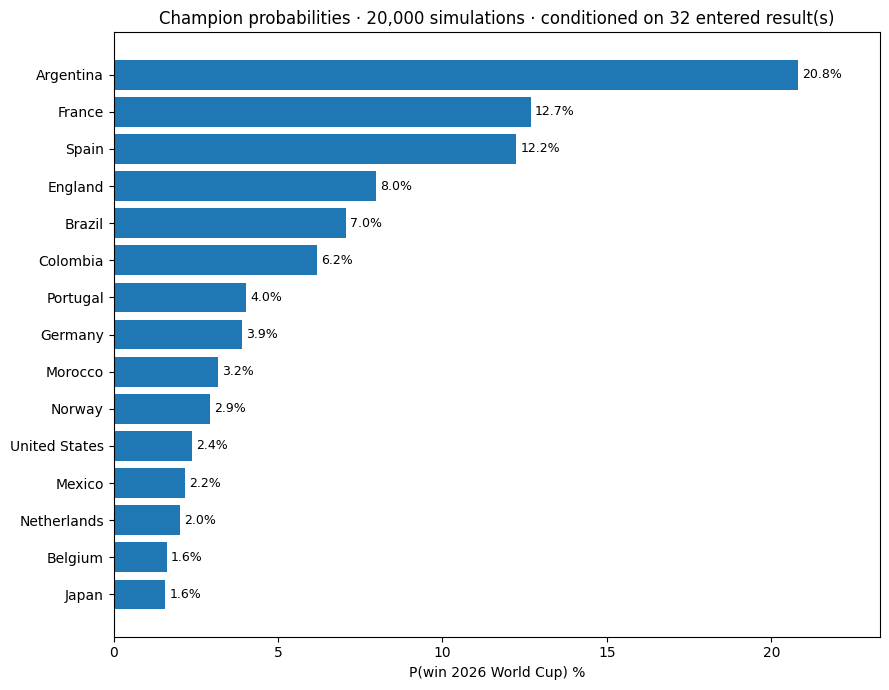

In [17]:
# ---------- 10c · Probabilities (rigorous Monte Carlo view) ----------
print("Title & stage probabilities (top 16):")
display(forecast.head(16).round(1))

top = forecast.head(15)[::-1]
fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(top["team"], top["champion_%"], color="#1f77b4")
ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=9)
ax.set_xlabel("P(win 2026 World Cup) %"); ax.margins(x=0.12)
ax.set_title(f"Champion probabilities · {N_SIMS:,} simulations · conditioned on {len(GROUP_ACTUAL)+len(KO_ACTUAL)} entered result(s)")
plt.tight_layout(); plt.show() # champion probabilities bar chart

## 12 · Honest limitations & benchmarks

| Team | This notebook (pre-tournament) | Opta | Zeileis/Groll |
|---|---|---|---|
| Spain | ~22 | 16.1 | 14.5 |
| Argentina | ~15 | 10.4 | — |
| England / France | ~7 each | 11–13 | 12.4 |
| Germany | ~2 | 5.7 | 11.2 |

Agrees with both independent models on **Spain as favourite** and an open field. We rate squad-rich sides
(France/England/Germany) a little lower because we learn from **results + Elo only**; Opta and the academic model add
**player ratings and market values** (no clean free CSV exists, so a reproducible notebook omits them). Other
documented simplifications: host edge only in group games; knockouts neutral; shootouts near-random; group
fair-play/lots tie-breaks approximated by a random draw; the projected bracket is one *modal* path (use §10c for
probabilities). **As you enter real results, both the strength estimates and the bracket update**, so mid-tournament
forecasts are conditioned on what actually happened.

---
**Reproducibility:** data `martj42/international_results` (CC0); methods Dixon–Coles (1997), Lasek et al. (2013),
Groll/Zeileis (2018–2026). Seeded (`RNG_SEED=42`). To use live: edit §4 after each match, then *Restart & Run All*.